### AIM
Why customer churn from our Company

**Import The libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/customer_churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Here total charges are object, but the total charges should be int


In [ ]:
for i in df.columns:
  print(df[i].value_counts())

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    15

In [ ]:
(df['TotalCharges']==' ').sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df[df['tenure']==0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

We dont want those customer who's tenure is 0, so we drop them.



In [ ]:
df.drop(df[df['tenure']==0].index,inplace=True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


We also dont need of customer id column so we drop the customer id column

In [ ]:
df=df.drop('customerID',axis=1)

In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094
TechSupport,7032,3,No,3472


### one hot encoding

In [ ]:
df2 = df


In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [ ]:
dummy = pd.get_dummies(df2)
dummy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,False,True,False,True,False,...,True,False,True,False,False,True,False,False,False,True
7039,0,72,103.20,7362.90,0,True,False,False,True,False,...,True,False,True,False,False,True,False,True,False,False
7040,0,11,29.60,346.45,0,True,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False
7041,1,4,74.40,306.60,1,False,True,False,True,True,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
corr=dummy.corr()['Churn']


<Axes: >

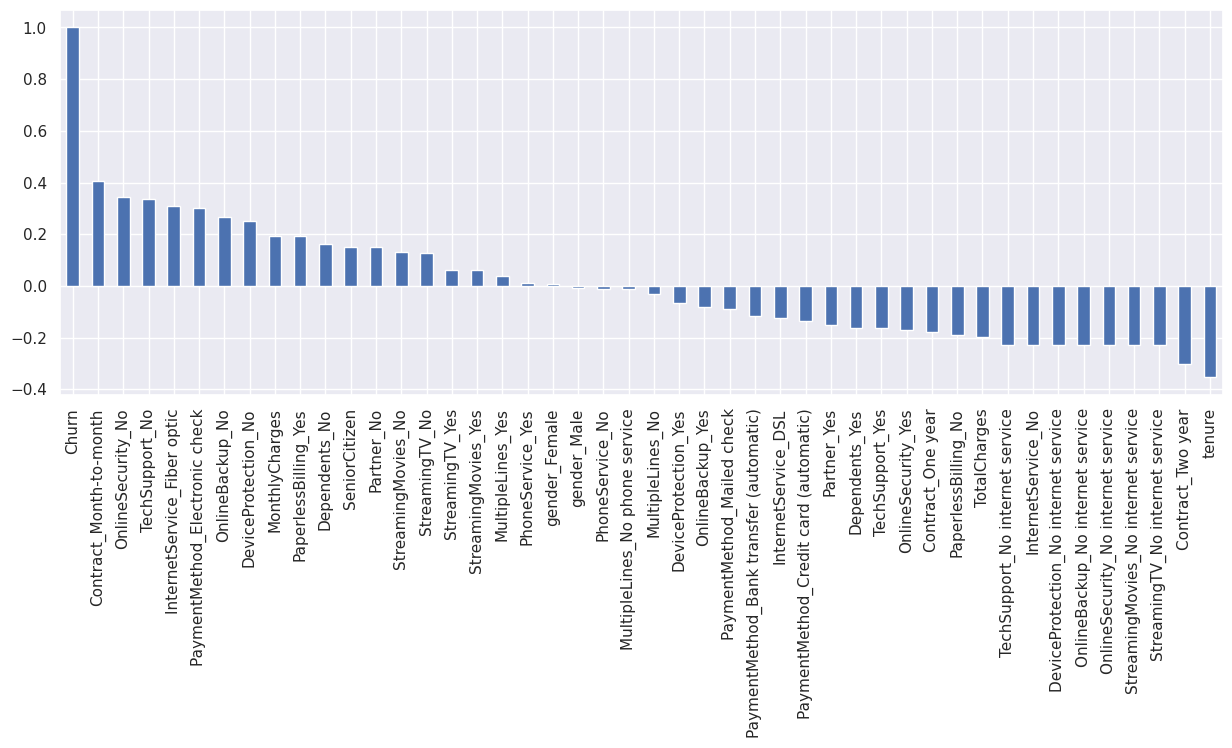

In [ ]:
plt.figure(figsize=(15,5))
sns.set(style='darkgrid')
dummy.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Visulaization of the data

In [ ]:

fig = px.histogram(df,x='Churn',color='gender',barmode='group',title='<b>Churn distribution w.r.t Gender<b>',color_discrete_map={'Female':'pink','Male':'skyblue'})
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

In [ ]:
fig = px.histogram(df,x='Churn',color='SeniorCitizen',barmode='group',title='<b>Churn distribution w.r.t SeniorCitizen<b>')
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

* 16% of the customer who are senior ctitzen are use our services.
* 6.7% of customer who are senior citizen was churn out
* 20% of the customer who are not senior citizen was churn out

In [ ]:
fig = px.histogram(df,x='Churn',color='Partner',barmode='group',title='<b>Churn distribution w.r.t Partner<b>')
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

mostly Customer who dont have a partner was churn out

In [ ]:
fig = px.histogram(df,x='Churn',color='Contract',barmode='group',title='<b>Churn distribution w.r.t Dependents<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

* There are 56% customer who have contract with Month-to-Month
* 20% customer have One year contract with us
* 24% customer have two year contract
* 23% customer who have a month to month contract was churn out
* 2% customer churn out who have one year contract
* 0.5% customer who have two year contract was churn out

In [ ]:
fig = px.histogram(df,x='Churn',color='PaymentMethod',title='<b>Churn distribution w.r.t PaymentMethod<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

33% customer used electronic check as payment method
* Moatly customer who use electronic check as payment method were moved out in compare to others

In [ ]:
fig = px.histogram(df,x='Churn',color='OnlineSecurity',title='<b>Churn distribution w.r.t OnlineSecurity<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

Mostly customers who have no online security were moved out

### Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x]=le.fit_transform(df[x])

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [ ]:
x = df.drop(columns = ['PhoneService','gender','Churn'])
y = df['Churn']

In [ ]:
x_res,y_res = smote.fit_resample(x,y)

In [ ]:
pd.Series(y_res).value_counts()

,count
Churn,
0,5163
1,5163


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)

In [ ]:
x_train

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
9031,0,0,0,14,2,0,0,0,0,2,0,0,0,0,1,56.670303,754.701239
8100,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,70.653157,70.653157
8400,0,0,0,23,2,1,0,0,0,0,0,0,0,1,0,78.221047,1842.862398
828,0,1,0,50,2,1,2,2,0,2,2,2,1,0,2,108.550000,5610.700000
6964,0,1,1,24,2,0,2,2,2,0,0,0,2,0,2,64.350000,1558.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1,0,0,38,0,2,1,1,1,1,1,1,2,0,3,20.200000,735.900000
5191,0,0,0,51,2,1,0,2,2,2,2,2,1,1,2,111.500000,5703.250000
5390,0,0,0,50,0,2,1,1,1,1,1,1,1,0,0,19.750000,989.050000
860,1,1,0,20,0,1,0,2,0,0,0,0,0,1,2,73.650000,1463.500000


In [ ]:
y_train

,Churn
9031,1
8100,1
8400,1
828,1
6964,0
...,...
5734,0
5191,0
5390,0
860,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
x_train

array([[-0.394626  , -0.7746967 , -0.51922759, ..., -0.55947353,
        -0.40967597, -0.59655857],
       [-0.394626  , -0.7746967 , -0.51922759, ...,  0.44383767,
         0.07862666, -0.91015168],
       [-0.394626  , -0.7746967 , -0.51922759, ..., -1.56278473,
         0.34290895, -0.09770496],
       ...,
       [-0.394626  , -0.7746967 , -0.51922759, ..., -1.56278473,
        -1.69898937, -0.48912437],
       [ 2.53404492,  1.29082775, -0.51922759, ...,  0.44383767,
         0.18328099, -0.27161882],
       [-0.394626  , -0.7746967 , -0.51922759, ...,  1.44714886,
        -1.67413647, -0.93316133]])

In [ ]:
'''
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lr = LogisticRegression() '''

In [ ]:
'''
from sklearn.model_selection import GridSearchCV
parameter = {'penalty':['l1','l2','elasticnet'],'C':[1,2,3,4,5,6,10,20,30],'solver':['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],'max_iter':[100,200,300,500,700]}
'''

In [ ]:
'''gride = GridSearchCV(lr,param_grid=parameter,cv=5,scoring='accuracy')'''

In [ ]:
'''module = gride.fit(x_train,y_train)'''

In [ ]:
'''print(module.best_params_)
print(module.best_score_)'''

{'C': 10, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
0.7974576271186441


In [ ]:
'''pred = gride.predict(x_test)'''

In [ ]:
'''print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))'''

0.7942884801548886
[[780 257]
 [168 861]]
              precision    recall  f1-score   support

           0       0.82      0.75      0.79      1037
           1       0.77      0.84      0.80      1029

    accuracy                           0.79      2066
   macro avg       0.80      0.79      0.79      2066
weighted avg       0.80      0.79      0.79      2066



In [ ]:
import tensorflow as tf


In [ ]:
model = tf.keras.models.Sequential()

In [ ]:
x_train.shape

(8260, 17)

In [ ]:
len(x_train[0:])

8260

In [ ]:
p=x_train.flatten()

In [ ]:
len(p)

140420

In [ ]:
x_train.shape[0:]

(8260, 17)

In [ ]:
model.add(tf.keras.layers.Flatten(input_shape=x_train.shape[1:]))

model.add(tf.keras.layers.Dense(
    units=128,
    activation=tf.keras.activations.relu))

model.add(tf.keras.layers.Dense(
    units=128,
    activation=tf.keras.activations.relu))


model.add(tf.keras.layers.Dense(
    units=10,
    activation=tf.keras.activations.softmax))

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,106 (78.54 KB)

 Trainable params: 20,106 (78.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
model.compile(
    optimizer=adam_optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
final=model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test))

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7671 - loss: 0.5401 - val_accuracy: 0.7909 - val_loss: 0.4573
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4212 - val_accuracy: 0.7803 - val_loss: 0.4645
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8039 - loss: 0.4201 - val_accuracy: 0.8117 - val_loss: 0.4306
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8156 - loss: 0.3912 - val_accuracy: 0.8117 - val_loss: 0.4228
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8174 - loss: 0.3969 - val_accuracy: 0.8107 - val_loss: 0.4121
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8180 - loss: 0.3799 - val_accuracy: 0.8069 - val_loss: 0.4236
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8244 - loss: 0.3724 - val_accuracy: 0.8078 - val_loss: 0.4033
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8276 - loss: 0.3641 - val_accuracy: 0.

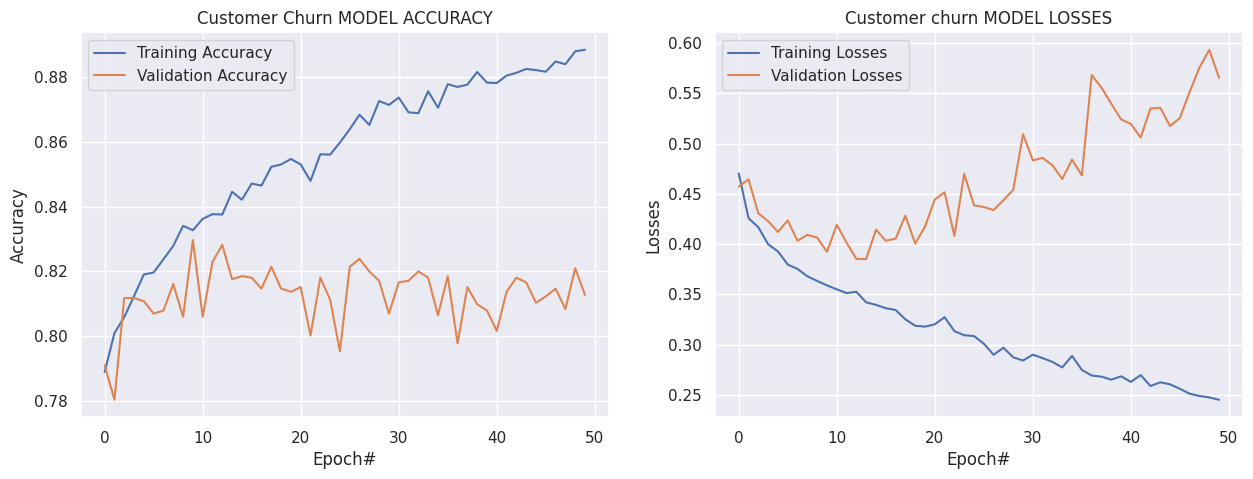

In [ ]:
plt.subplots(1,2,figsize=(15,5))

plt.subplot(1,2,1)
sns.lineplot(final.history['accuracy'],label = 'Training Accuracy')
sns.lineplot(final.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch#')
plt.ylabel('Accuracy')
plt.title('Customer Churn MODEL ACCURACY')

plt.subplot(1,2,2)
sns.lineplot(final.history['loss'], label = 'Training Losses')
sns.lineplot(final.history['val_loss'], label = 'Validation Losses')
plt.xlabel('Epoch#')
plt.ylabel('Losses')
plt.title('Customer churn MODEL LOSSES')
plt.show()